In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# craete a llm
llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    profile={
        "max_input_tokens":131072
    }
)

# create a state type
class State(TypedDict):
    messages: Annotated[list, add_messages]

# create node (say chatbot)
def chatbot(state: State)->str:
    return {"messages": [llm.invoke(state["messages"])]}

# create graph builder
graph_builder = StateGraph(State)

# bind with nodes
graph_builder.add_node("Chat_Bot_Node", chatbot)

# craete edges
graph_builder.add_edge(START, "Chat_Bot_Node")
graph_builder.add_edge("Chat_Bot_Node", END)

# compile the graph
graph = graph_builder.compile()

In [ ]:
llm.invoke("test")

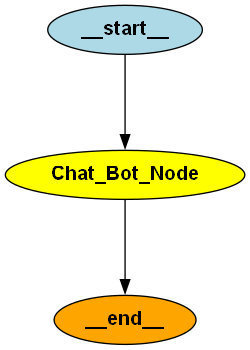

In [3]:
# Display the Graph

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_png()
    )
)

In [8]:
res = graph.invoke({
    "messages": "hi"
})
res["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User said: "hi"\n   - This is a simple greeting.\n\n2.  **Identify Intent:**\n   - The user is initiating a conversation.\n   - Expected response: A friendly greeting back, possibly with an offer to help.\n\n3.  **Determine Response Strategy:**\n   - Keep it warm and concise.\n   - Acknowledge the greeting.\n   - Invite the user to ask a question or state what they need help with.\n   - Maintain a helpful and approachable tone.\n\n4.  **Draft Response (Mental):**\n   - "Hello! How can I assist you today?"\n   - "Hi there! What\'s on your mind? I\'m here to help."\n   - "Hey! How can I help you today?"\n\n5.  **Refine Response:**\n   - Keep it simple and professional but friendly.\n   - "Hello! How can I help you today?" is standard and effective.\n\n6.  **Final Output Generation:** (matches the refined version)\n   - "Hello! How can I assist you today?" ✅\n\n   Self-Correction/Verification during thought:\n   

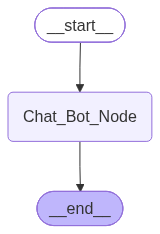

In [14]:
# print(res["messages"][-1].content)
graph

In [19]:
# Streaming the graph output
for event in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}):
    for value in event.values():
        print(value["messages"][-1].content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Topic:** 'AIML' (Artificial Intelligence and Machine Learning)
   - **Format:** Medium paragraph
   - **Goal:** Provide a concise, informative paragraph about AIML

2.  **Define AIML:**
   - AI (Artificial Intelligence): Broad field of computer science focused on creating systems capable of performing tasks that typically require human intelligence (reasoning, learning, perception, decision-making).
   - ML (Machine Learning): A subset of AI that focuses on algorithms and statistical models that enable computers to improve at tasks through experience/data without being explicitly programmed for every rule.
   - Together: AIML represents the convergence of these fields, driving innovation across industries.

3.  **Identify Key Points to Cover in a Medium Paragraph:**
   - Definition/relationship between AI and ML
   - How they work together (data-driven learning, pattern recognition, automation)
   - Real-world appl